# Credix — evaluation.ipynb

Notebook limpo para avaliação do modelo usando a **ABT final** do projeto:

```text
gold/abt.csv
```

Este notebook substitui o fluxo antigo que tentava localizar automaticamente qualquer base com `TARGET`. A partir daqui, a avaliação fica fixa e coerente com o storytelling do TCC:

```text
Application Train + Bureau → Feature Engineering → ABT → XGBoost → Métricas e gráficos
```

In [1]:
# ============================================================
# 1. Configuração inicial do projeto Credix
# ============================================================

import os
import sys
import json
import pickle
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

# Descobre a raiz do projeto mesmo se o notebook estiver dentro de /notebooks
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() in ["notebooks", "model", "models"]:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
GOLD_DIR = PROJECT_ROOT / "gold"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("GOLD_DIR:", GOLD_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

PROJECT_ROOT: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix
GOLD_DIR: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\gold
MODELS_DIR: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\models
FIGURES_DIR: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures


In [2]:
# ============================================================
# 2. Carregar ABT final do projeto Credix
# ============================================================

ABT_PATH = PROJECT_ROOT / "gold" / "abt.csv"

if not ABT_PATH.exists():
    raise FileNotFoundError(f"ABT não encontrada em: {ABT_PATH}")

df = pd.read_csv(ABT_PATH)

print("ABT carregada de:", ABT_PATH)
print("Shape da ABT:", df.shape)

print()
print("Primeiras colunas:")
print(df.columns.tolist()[:30])

print()
print("Distribuição do TARGET:")
display(
    df["TARGET"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame("percentual")
)

display(df.head())


ABT carregada de: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\gold\abt.csv
Shape da ABT: (307511, 21)

Primeiras colunas:
['SK_ID_CURR', 'TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'IDADE', 'TEMPO_EMPRESA', 'CREDITO_RENDA', 'PARCELA_RENDA', 'BEM_RENDA', 'RENDA_LIVRE', 'COMPROMETIMENTO_RENDA', 'PRAZO_ESTIMADO', 'BUREAU_QTD_CREDITOS', 'BUREAU_QTD_ATIVOS', 'BUREAU_TOTAL_CREDITO', 'BUREAU_TOTAL_DIVIDA', 'BUREAU_DEBT_RATIO']

Distribuição do TARGET:


,percentual
TARGET,
0,91.93
1,8.07


,SK_ID_CURR,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,IDADE,TEMPO_EMPRESA,...,PARCELA_RENDA,BEM_RENDA,RENDA_LIVRE,COMPROMETIMENTO_RENDA,PRAZO_ESTIMADO,BUREAU_QTD_CREDITOS,BUREAU_QTD_ATIVOS,BUREAU_TOTAL_CREDITO,BUREAU_TOTAL_DIVIDA,BUREAU_DEBT_RATIO
0,100002,1,202500.0,406597.5,24700.5,351000.0,Secondary / secondary special,Single / not married,25.92,1.75,...,0.12,1.73,177799.5,0.12,16.46,8.0,2.0,865055.565,245781.0,0.284122
1,100003,0,270000.0,1293502.5,35698.5,1129500.0,Higher education,Married,45.93,3.25,...,0.13,4.18,234301.5,0.13,36.23,4.0,1.0,1017400.500,0.0,0.000000
2,100004,0,67500.0,135000.0,6750.0,135000.0,Secondary / secondary special,Single / not married,52.18,0.62,...,0.10,2.00,60750.0,0.10,20.00,2.0,0.0,189037.800,0.0,0.000000
3,100006,0,135000.0,312682.5,29686.5,297000.0,Secondary / secondary special,Civil marriage,52.07,8.33,...,0.22,2.20,105313.5,0.22,10.53,0.0,0.0,0.000,0.0,0.000000
4,100007,0,121500.0,513000.0,21865.5,513000.0,Secondary / secondary special,Single / not married,54.61,8.32,...,0.18,4.22,99634.5,0.18,23.46,1.0,0.0,146250.000,0.0,0.000000


In [3]:
# ============================================================
# 3. Conferência: garantir que a base é a ABT correta
# ============================================================

print("Colunas com RENDA:")
print([c for c in df.columns if "RENDA" in c.upper()])

print()
print("Colunas com BUREAU:")
print([c for c in df.columns if "BUREAU" in c.upper()])

features_obrigatorias = [
    "CREDITO_RENDA",
    "PARCELA_RENDA",
    "RENDA_LIVRE",
    "COMPROMETIMENTO_RENDA",
    "BUREAU_QTD_CREDITOS",
    "BUREAU_QTD_ATIVOS",
    "BUREAU_TOTAL_CREDITO",
    "BUREAU_TOTAL_DIVIDA",
    "BUREAU_DEBT_RATIO",
]

faltantes = [c for c in features_obrigatorias if c not in df.columns]

if faltantes:
    raise ValueError(f"A base carregada não parece ser a ABT final. Features faltantes: {faltantes}")
else:
    print()
    print("OK: ABT final validada com sucesso.")


Colunas com RENDA:
['CREDITO_RENDA', 'PARCELA_RENDA', 'BEM_RENDA', 'RENDA_LIVRE', 'COMPROMETIMENTO_RENDA']

Colunas com BUREAU:
['BUREAU_QTD_CREDITOS', 'BUREAU_QTD_ATIVOS', 'BUREAU_TOTAL_CREDITO', 'BUREAU_TOTAL_DIVIDA', 'BUREAU_DEBT_RATIO']

OK: ABT final validada com sucesso.


In [4]:
# ============================================================
# 4. Preparação dos dados para modelagem com a ABT correta
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Remove linhas sem TARGET
model_df = df.dropna(subset=["TARGET"]).copy()

# Remove identificador do cliente
id_cols = ["SK_ID_CURR"]
id_cols = [c for c in id_cols if c in model_df.columns]

X = model_df.drop(columns=["TARGET"] + id_cols, errors="ignore")
y = model_df["TARGET"].astype(int)

# Categóricas conhecidas na ABT
categorical_features = [
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
]
categorical_features = [c for c in categorical_features if c in X.columns]

# Numéricas = todas as demais
numeric_features = [c for c in X.columns if c not in categorical_features]

# Garante que as numéricas realmente estão numéricas
for col in numeric_features:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# Garante que categóricas estão como texto/object
for col in categorical_features:
    X[col] = X[col].astype("object")

print("Quantidade de features totais:", X.shape[1])
print("Features numéricas:", len(numeric_features))
print(numeric_features)

print()
print("Features categóricas:", len(categorical_features))
print(categorical_features)

print()
print("Taxa de inadimplência:")
print(round(y.mean() * 100, 2), "%")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Compatibilidade com versões diferentes do scikit-learn
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", onehot)
            ]),
            categorical_features
        )
    ],
    remainder="drop"
)

print()
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)


Quantidade de features totais: 19
Features numéricas: 17
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'IDADE', 'TEMPO_EMPRESA', 'CREDITO_RENDA', 'PARCELA_RENDA', 'BEM_RENDA', 'RENDA_LIVRE', 'COMPROMETIMENTO_RENDA', 'PRAZO_ESTIMADO', 'BUREAU_QTD_CREDITOS', 'BUREAU_QTD_ATIVOS', 'BUREAU_TOTAL_CREDITO', 'BUREAU_TOTAL_DIVIDA', 'BUREAU_DEBT_RATIO']

Features categóricas: 2
['NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']

Taxa de inadimplência:
8.07 %

Treino: (246008, 19)
Teste: (61503, 19)


In [5]:
# ============================================================
# 5. Remover modelo antigo, se existir
# ============================================================

old_model_path = MODELS_DIR / "xgboost_model.pkl"

if old_model_path.exists():
    old_model_path.unlink()
    print("Modelo antigo removido:", old_model_path)
else:
    print("Nenhum modelo antigo encontrado.")

Modelo antigo removido: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\models\xgboost_model.pkl


In [6]:
# ============================================================
# 6. Treinar modelo novo com Pipeline completa usando a ABT
# Usa model_pipeline para evitar sobrescrita por células antigas
# ============================================================

import joblib
from sklearn.pipeline import Pipeline

print("Treinando novo modelo com pré-processamento + XGBoost usando a ABT...")

try:
    from xgboost import XGBClassifier

    # Peso para ajudar no desbalanceamento da classe TARGET=1
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / max(pos, 1)

    clf = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    )

    model_name = "XGBoost"

except Exception as e:
    print("XGBoost não disponível. Usando RandomForest como fallback.")
    print("Erro:", e)

    from sklearn.ensemble import RandomForestClassifier

    clf = RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    )

    model_name = "RandomForest fallback"

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", clf)
])

model_pipeline.fit(X_train, y_train)

model_path = MODELS_DIR / "xgboost_model.pkl"
joblib.dump(model_pipeline, model_path)

# Mantém também em model para compatibilidade, mas daqui em diante usar model_pipeline
model = model_pipeline

print(f"Modelo treinado com sucesso: {model_name}")
print(f"Modelo salvo em: {model_path}")
print("Tipo do model_pipeline:", type(model_pipeline))
print("Tipo do model:", type(model))

Treinando novo modelo com pré-processamento + XGBoost usando a ABT...
Modelo treinado com sucesso: XGBoost
Modelo salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\models\xgboost_model.pkl
Tipo do model_pipeline: <class 'sklearn.pipeline.Pipeline'>
Tipo do model: <class 'sklearn.pipeline.Pipeline'>


In [7]:
# ============================================================
# 7. Diagnóstico do pipeline treinado
# ============================================================

print("Tipo atual do model_pipeline:", type(model_pipeline))
print("Tipo atual do model:", type(model))

if hasattr(model_pipeline, "named_steps"):
    print("model_pipeline é Pipeline.")
    print("Etapas:", model_pipeline.named_steps.keys())
else:
    raise TypeError("model_pipeline NÃO é Pipeline.")

# Teste rápido do pré-processamento
X_sample_teste = X_test.sample(min(10, len(X_test)), random_state=42)
X_transformed_teste = model_pipeline.named_steps["preprocessor"].transform(X_sample_teste)

teste_df = pd.DataFrame(X_transformed_teste)

print()
print("Shape original:", X_sample_teste.shape)
print("Shape transformado:", X_transformed_teste.shape)
print()
print("Tipos depois do preprocessor:")
print(teste_df.dtypes.value_counts())


Tipo atual do model_pipeline: <class 'sklearn.pipeline.Pipeline'>
Tipo atual do model: <class 'sklearn.pipeline.Pipeline'>
model_pipeline é Pipeline.
Etapas: dict_keys(['preprocessor', 'classifier'])

Shape original: (10, 19)
Shape transformado: (10, 28)

Tipos depois do preprocessor:
float64    28
Name: count, dtype: int64


In [8]:
# ============================================================
# 8. Previsões e métricas principais
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score
)

y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1_score": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "average_precision": average_precision_score(y_test, y_proba),
}

metrics_df = pd.DataFrame([metrics]).T.rename(columns={0: "valor"})
display(metrics_df.style.format("{:.4f}"))

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

metrics_path = REPORTS_DIR / "evaluation_metrics.json"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump({k: float(v) for k, v in metrics.items()}, f, indent=4)

print("Métricas salvas em:", metrics_path)

,valor
accuracy,0.6716
precision,0.1465
recall,0.6361
f1_score,0.2382
roc_auc,0.7120
average_precision,0.1909


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.67      0.79     56538
           1       0.15      0.64      0.24      4965

    accuracy                           0.67     61503
   macro avg       0.55      0.66      0.51     61503
weighted avg       0.89      0.67      0.75     61503

Métricas salvas em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\evaluation_metrics.json


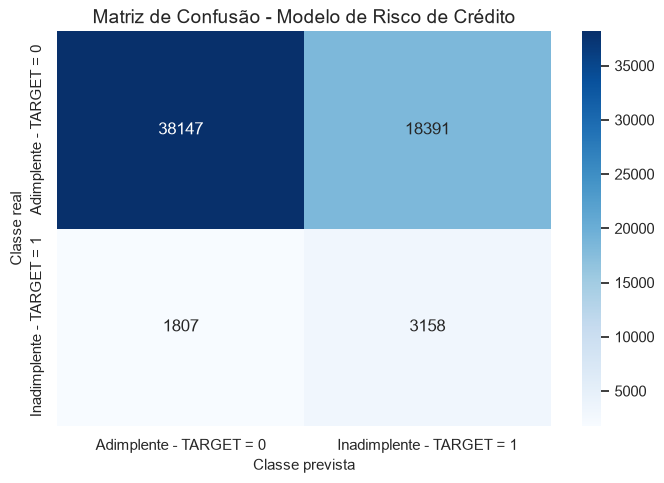

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\evaluation_confusion_matrix.png


In [9]:
# ============================================================
# 9. Gráfico: Matriz de Confusão
# ============================================================

cm = confusion_matrix(y_test, y_pred)
cm_labels = ["Adimplente - TARGET = 0", "Inadimplente - TARGET = 1"]

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=cm_labels,
    yticklabels=cm_labels
)
plt.title("Matriz de Confusão - Modelo de Risco de Crédito")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.tight_layout()

output_path = FIGURES_DIR / "evaluation_confusion_matrix.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico salvo em:", output_path)


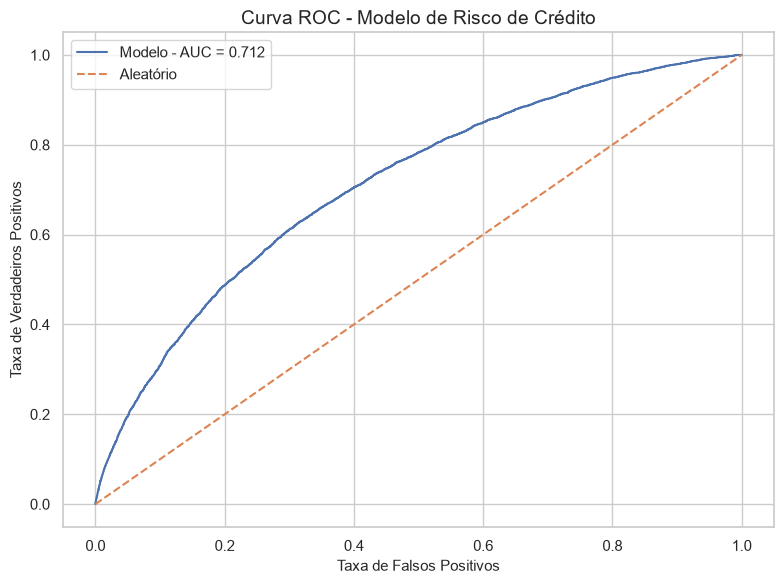

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\evaluation_roc_curve.png


In [10]:
# ============================================================
# 10. Gráfico: Curva ROC
# ============================================================

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_value = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Modelo - AUC = {auc_value:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Aleatório")
plt.title("Curva ROC - Modelo de Risco de Crédito")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.legend()
plt.grid(True)
plt.tight_layout()

output_path = FIGURES_DIR / "evaluation_roc_curve.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico salvo em:", output_path)

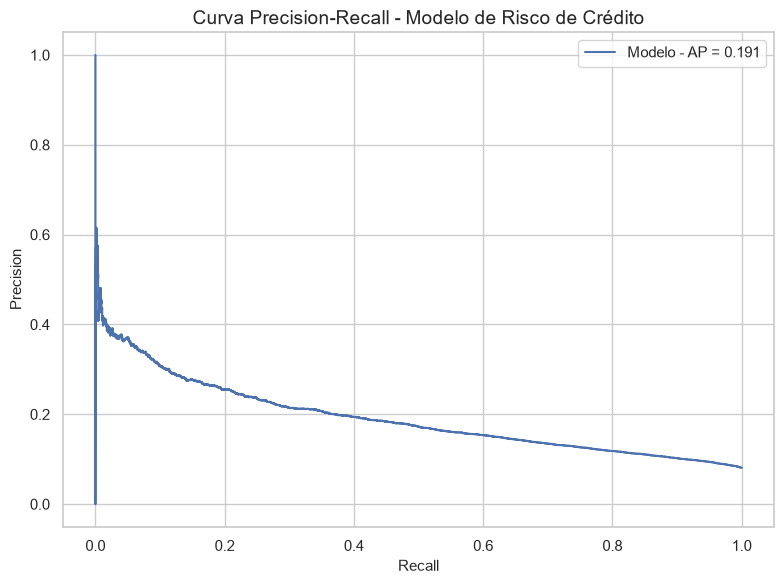

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\evaluation_precision_recall_curve.png


In [11]:
# ============================================================
# 11. Gráfico: Precision-Recall Curve
# ============================================================

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
ap_value = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"Modelo - AP = {ap_value:.3f}")
plt.title("Curva Precision-Recall - Modelo de Risco de Crédito")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.tight_layout()

output_path = FIGURES_DIR / "evaluation_precision_recall_curve.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico salvo em:", output_path)

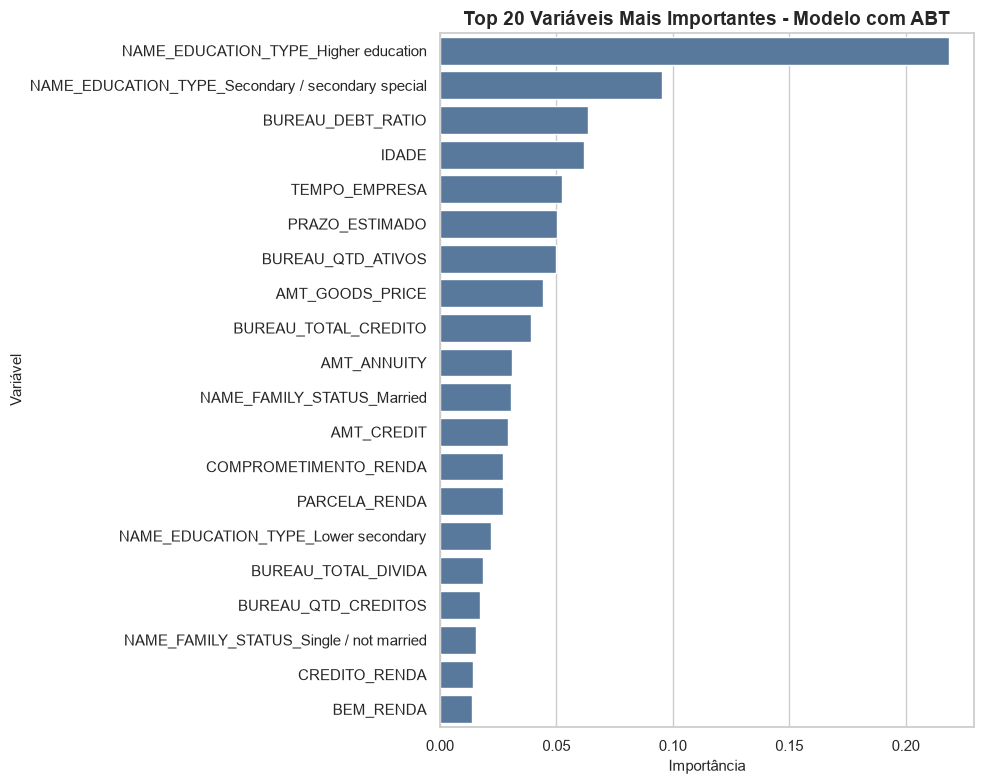

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\evaluation_feature_importance_abt.png


,feature,importance
18,NAME_EDUCATION_TYPE_Higher education,0.218392
21,NAME_EDUCATION_TYPE_Secondary / secondary special,0.095178
16,BUREAU_DEBT_RATIO,0.063714
4,IDADE,0.061761
5,TEMPO_EMPRESA,0.052373
11,PRAZO_ESTIMADO,0.050191
13,BUREAU_QTD_ATIVOS,0.049711
3,AMT_GOODS_PRICE,0.044388
14,BUREAU_TOTAL_CREDITO,0.039120
2,AMT_ANNUITY,0.030905


In [12]:
# ============================================================
# 12. Feature Importance corrigido para modelo treinado com ABT
# ============================================================

def get_feature_names_from_pipeline(pipe):
    preprocessor_local = pipe.named_steps["preprocessor"]
    feature_names = []

    for name, transformer, cols in preprocessor_local.transformers_:
        if name == "num":
            feature_names.extend(list(cols))

        elif name == "cat":
            ohe = transformer.named_steps["onehot"]
            encoded_names = ohe.get_feature_names_out(cols)
            feature_names.extend(encoded_names)

    return feature_names

classifier = model_pipeline.named_steps["classifier"]
feature_names = get_feature_names_from_pipeline(model_pipeline)

if hasattr(classifier, "feature_importances_"):
    importances = classifier.feature_importances_
else:
    raise AttributeError("O classificador não possui feature_importances_.")

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

top_n = 20
plot_df = fi_df.head(top_n)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=plot_df,
    x="importance",
    y="feature",
    color="#4C78A8"
)

plt.title("Top 20 Variáveis Mais Importantes - Modelo com ABT", fontsize=14, fontweight="bold")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()

output_path = FIGURES_DIR / "evaluation_feature_importance_abt.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico salvo em:", output_path)
display(fi_df.head(30))

In [13]:
# ============================================================
# 13. Conferência final dos arquivos gerados
# ============================================================

print("Figuras geradas:")
for p in sorted(FIGURES_DIR.glob("*.png")):
    print("-", p.name)

Figuras geradas:
- abt_features_corr_target.png
- eda_age_distribution.png
- eda_correlation_heatmap.png
- eda_credit_by_target.png
- eda_income_distribution.png
- eda_target_distribution.png
- evaluation_confusion_matrix.png
- evaluation_feature_importance_abt.png
- evaluation_precision_recall_curve.png
- evaluation_roc_curve.png
- insight_1_target_barras.png
- insight_1_target_pizza.png
- insight_2_renda_boxplot.png
- insight_2_renda_histograma.png
- insight_3_debt_ratio_proxy_boxplot.png
- monitoring_distribution_drift_example.png
- monitoring_psi_top_features.png
- shap_bar_plot.png
- shap_summary_plot.png


## Como explicar estes resultados para a banca

- **ABT**: a base `gold/abt.csv` consolida dados cadastrais, financeiros e de bureau em uma visão única por cliente.
- **Pipeline**: o modelo usa pré-processamento + XGBoost para tratar variáveis numéricas e categóricas corretamente.
- **ROC AUC**: mede a capacidade de separação entre clientes adimplentes e inadimplentes.
- **Matriz de confusão**: mostra acertos e erros do modelo por classe.
- **Precision-Recall**: é útil porque a base é desbalanceada.
- **Feature Importance ABT**: demonstra que as variáveis criadas na engenharia de atributos foram efetivamente usadas pelo modelo.

## Imagens para Slide de Modelagem

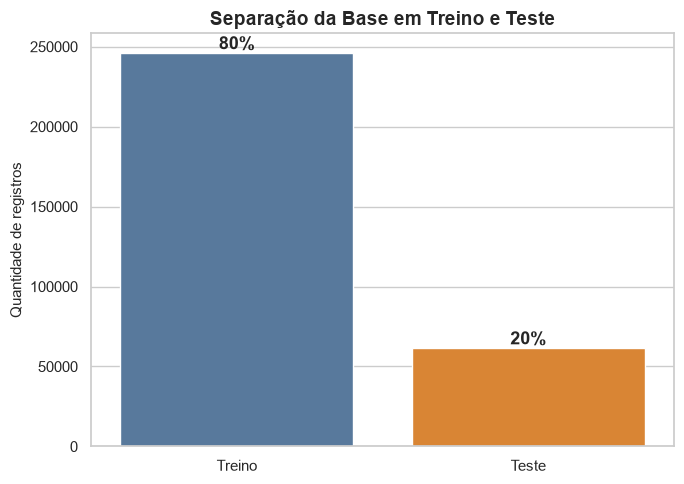

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\model_split_train_test.png


In [14]:
# ============================================================
# Imagem 1 - Split treino/teste
# ============================================================

train_count = len(X_train)
test_count = len(X_test)

split_df = pd.DataFrame({
    "Base": ["Treino", "Teste"],
    "Quantidade": [train_count, test_count],
    "Percentual": [
        train_count / (train_count + test_count) * 100,
        test_count / (train_count + test_count) * 100
    ]
})

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=split_df,
    x="Base",
    y="Quantidade",
    palette=["#4C78A8", "#F58518"]
)

for i, row in split_df.iterrows():
    ax.text(
        i,
        row["Quantidade"],
        f'{row["Percentual"]:.0f}%',
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

plt.title("Separação da Base em Treino e Teste", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.ylabel("Quantidade de registros")
plt.tight_layout()

output_path = FIGURES_DIR / "model_split_train_test.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico salvo em:", output_path)

Base usada para comparação: (60000, 19)
Treinando: Logistic Regression
Treinando: Random Forest
Treinando: MLP
Treinando: XGBoost


,Modelo,ROC AUC Treino,ROC AUC Teste,Average Precision,Precision,Recall,F1
3,XGBoost,0.7799,0.7009,0.1823,0.1451,0.6004,0.2337
1,Random Forest,0.7694,0.6767,0.1611,0.1419,0.5307,0.2239
0,Logistic Regression,0.6632,0.6616,0.1468,0.1242,0.6286,0.2075
2,MLP,0.6403,0.6387,0.1323,0.0000,0.0000,0.0000


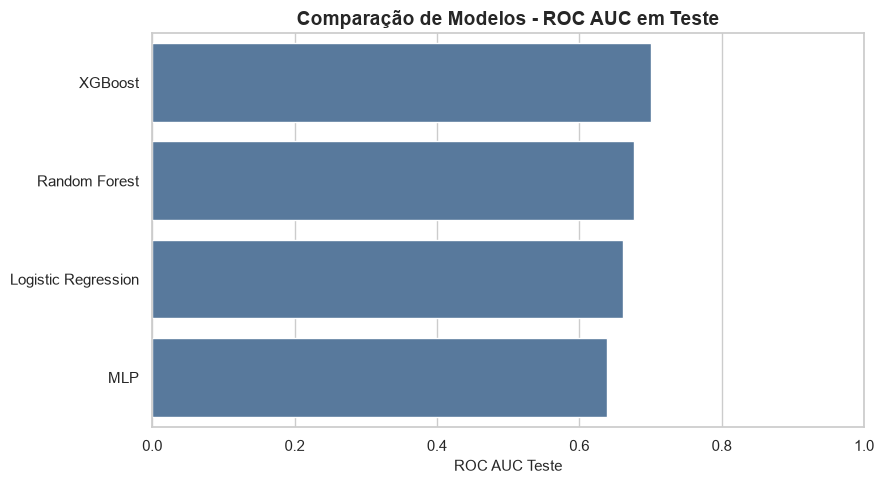

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\model_comparison_metrics.png


In [15]:
# ============================================================
# Imagem 2 - Comparação de Modelos
# Logistic Regression, Random Forest, MLP e XGBoost
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

try:
    from xgboost import XGBClassifier
    xgb_available = True
except Exception:
    xgb_available = False

# Para acelerar a comparação, usamos uma amostra do treino
COMPARISON_SAMPLE_SIZE = 60000

if COMPARISON_SAMPLE_SIZE is not None and len(X_train) > COMPARISON_SAMPLE_SIZE:
    sample_idx = X_train.sample(COMPARISON_SAMPLE_SIZE, random_state=42).index
    X_train_comp = X_train.loc[sample_idx]
    y_train_comp = y_train.loc[sample_idx]
else:
    X_train_comp = X_train.copy()
    y_train_comp = y_train.copy()

print("Base usada para comparação:", X_train_comp.shape)

# OneHot para modelos com escala
try:
    onehot_scaled = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_scaled = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", onehot_scaled)
            ]),
            categorical_features
        ),
    ],
    remainder="drop"
)

# OneHot sem escala para modelos de árvore
try:
    onehot_tree = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_tree = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", onehot_tree)
            ]),
            categorical_features
        ),
    ],
    remainder="drop"
)

models_to_compare = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("classifier", RandomForestClassifier(
            n_estimators=150,
            max_depth=8,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ]),
    "MLP": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("classifier", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=80,
            random_state=42,
            early_stopping=True
        ))
    ])
}

if xgb_available:
    neg = (y_train_comp == 0).sum()
    pos = (y_train_comp == 1).sum()
    scale_pos_weight_comp = neg / max(pos, 1)

    models_to_compare["XGBoost"] = Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("classifier", XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight_comp
        ))
    ])

comparison_rows = []

for model_name, pipe in models_to_compare.items():
    print("Treinando:", model_name)

    pipe.fit(X_train_comp, y_train_comp)

    train_proba = pipe.predict_proba(X_train_comp)[:, 1]
    test_proba = pipe.predict_proba(X_test)[:, 1]

    test_pred = (test_proba >= 0.5).astype(int)

    comparison_rows.append({
        "Modelo": model_name,
        "ROC AUC Treino": roc_auc_score(y_train_comp, train_proba),
        "ROC AUC Teste": roc_auc_score(y_test, test_proba),
        "Average Precision": average_precision_score(y_test, test_proba),
        "Precision": precision_score(y_test, test_pred, zero_division=0),
        "Recall": recall_score(y_test, test_pred, zero_division=0),
        "F1": f1_score(y_test, test_pred, zero_division=0)
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values("ROC AUC Teste", ascending=False)

display(comparison_df.style.format({
    "ROC AUC Treino": "{:.4f}",
    "ROC AUC Teste": "{:.4f}",
    "Average Precision": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
}))

plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison_df,
    x="ROC AUC Teste",
    y="Modelo",
    color="#4C78A8"
)

plt.title("Comparação de Modelos - ROC AUC em Teste", fontsize=14, fontweight="bold")
plt.xlabel("ROC AUC Teste")
plt.ylabel("")
plt.xlim(0, 1)
plt.tight_layout()

output_path = FIGURES_DIR / "model_comparison_metrics.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico salvo em:", output_path)

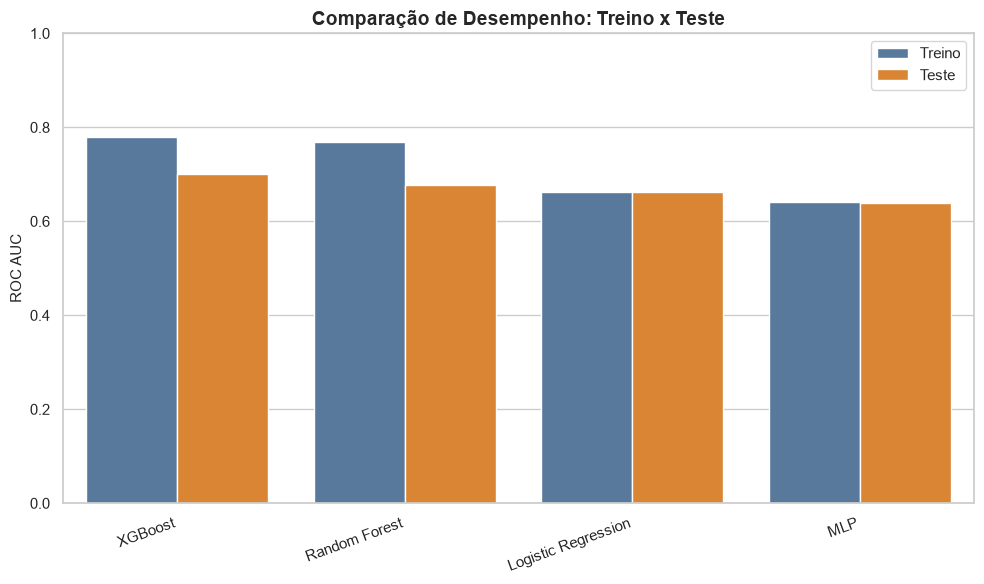

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\model_train_test_auc.png


In [16]:
# ============================================================
# Imagem 3 - Comparação Treino x Teste
# Evidência contra overfitting
# ============================================================

auc_long = comparison_df[["Modelo", "ROC AUC Treino", "ROC AUC Teste"]].melt(
    id_vars="Modelo",
    var_name="Base",
    value_name="ROC AUC"
)

auc_long["Base"] = auc_long["Base"].replace({
    "ROC AUC Treino": "Treino",
    "ROC AUC Teste": "Teste"
})

plt.figure(figsize=(10, 6))

sns.barplot(
    data=auc_long,
    x="Modelo",
    y="ROC AUC",
    hue="Base",
    palette=["#4C78A8", "#F58518"]
)

plt.title("Comparação de Desempenho: Treino x Teste", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.ylabel("ROC AUC")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="")
plt.tight_layout()

output_path = FIGURES_DIR / "model_train_test_auc.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico salvo em:", output_path)

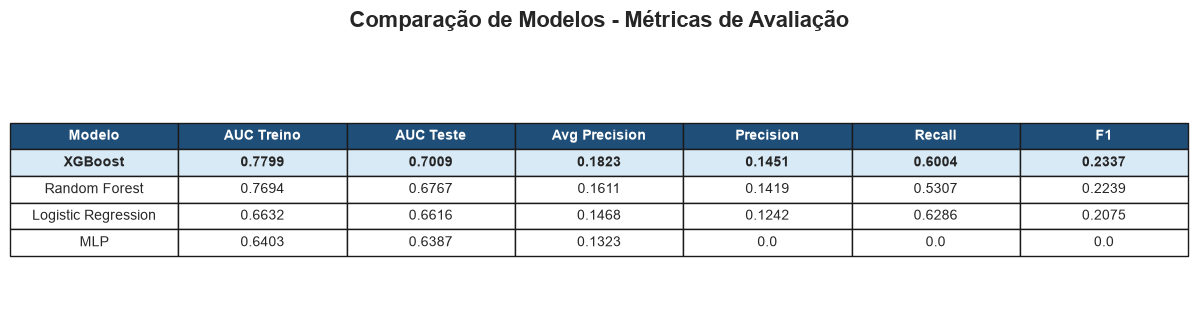

Tabela salva em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\model_comparison_table.png


In [17]:
# ============================================================
# Imagem - Tabela Comparativa dos Modelos
# ============================================================

# Seleciona e organiza as colunas principais
comparison_table = comparison_df[
    [
        "Modelo",
        "ROC AUC Treino",
        "ROC AUC Teste",
        "Average Precision",
        "Precision",
        "Recall",
        "F1"
    ]
].copy()

# Arredonda valores
for col in comparison_table.columns:
    if col != "Modelo":
        comparison_table[col] = comparison_table[col].round(4)

# Renomeia colunas para ficar melhor no slide
comparison_table = comparison_table.rename(columns={
    "Modelo": "Modelo",
    "ROC AUC Treino": "AUC Treino",
    "ROC AUC Teste": "AUC Teste",
    "Average Precision": "Avg Precision",
    "Precision": "Precision",
    "Recall": "Recall",
    "F1": "F1"
})

# Cria figura
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.axis("off")

table = ax.table(
    cellText=comparison_table.values,
    colLabels=comparison_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

# Estilo da tabela
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.6)

# Cabeçalho
for col_idx in range(len(comparison_table.columns)):
    cell = table[0, col_idx]
    cell.set_facecolor("#1F4E79")
    cell.set_text_props(color="white", weight="bold")

# Destacar linha do XGBoost
for row_idx in range(1, len(comparison_table) + 1):
    modelo = comparison_table.iloc[row_idx - 1]["Modelo"]
    if modelo == "XGBoost":
        for col_idx in range(len(comparison_table.columns)):
            table[row_idx, col_idx].set_facecolor("#D9EAF7")
            table[row_idx, col_idx].set_text_props(weight="bold")

plt.title(
    "Comparação de Modelos - Métricas de Avaliação",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

output_path = FIGURES_DIR / "model_comparison_table.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Tabela salva em:", output_path)

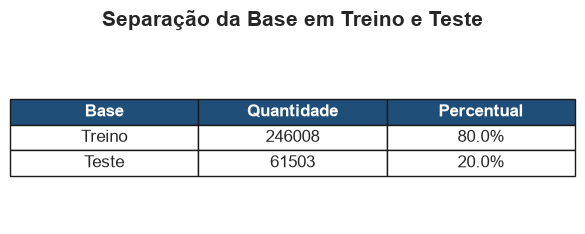

Tabela salva em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\model_split_train_test_table.png


In [18]:
# ============================================================
# Imagem - Tabela Split Treino/Teste
# ============================================================

split_table = split_df.copy()
split_table["Percentual"] = split_table["Percentual"].round(1).astype(str) + "%"

fig, ax = plt.subplots(figsize=(6, 2.5))
ax.axis("off")

table = ax.table(
    cellText=split_table.values,
    colLabels=split_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.7)

for col_idx in range(len(split_table.columns)):
    cell = table[0, col_idx]
    cell.set_facecolor("#1F4E79")
    cell.set_text_props(color="white", weight="bold")

plt.title(
    "Separação da Base em Treino e Teste",
    fontsize=15,
    fontweight="bold",
    pad=18
)

plt.tight_layout()

output_path = FIGURES_DIR / "model_split_train_test_table.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Tabela salva em:", output_path)

## Imagens para Slide de Avaliação

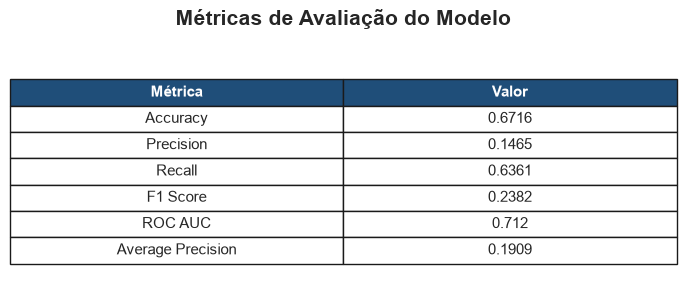

Tabela salva em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\evaluation_metrics_table.png


In [19]:
# ============================================================
# Imagem - Tabela de Métricas para Slide de Avaliação
# ============================================================

metrics_display = metrics_df.copy()
metrics_display = metrics_display.reset_index()
metrics_display.columns = ["Métrica", "Valor"]

metrics_display["Métrica"] = metrics_display["Métrica"].replace({
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1_score": "F1 Score",
    "roc_auc": "ROC AUC",
    "average_precision": "Average Precision"
})

metrics_display["Valor"] = metrics_display["Valor"].round(4)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.axis("off")

table = ax.table(
    cellText=metrics_display.values,
    colLabels=metrics_display.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.6)

# Estilizar cabeçalho
for col_idx in range(len(metrics_display.columns)):
    cell = table[0, col_idx]
    cell.set_facecolor("#1F4E79")
    cell.set_text_props(color="white", weight="bold")

plt.title(
    "Métricas de Avaliação do Modelo",
    fontsize=15,
    fontweight="bold",
    pad=18
)

plt.tight_layout()

output_path = FIGURES_DIR / "evaluation_metrics_table.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Tabela salva em:", output_path)

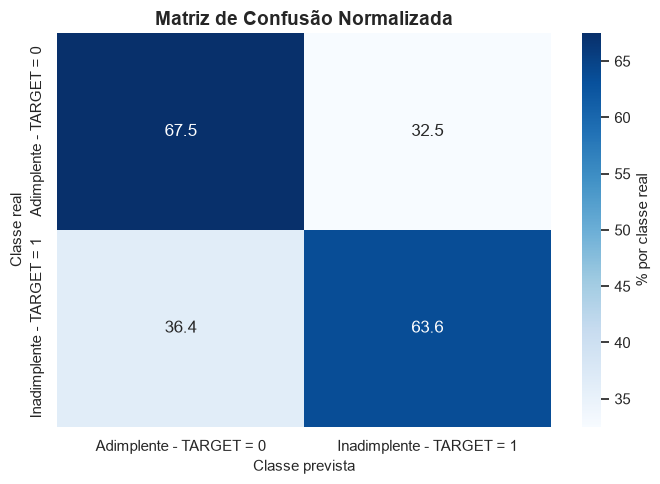

Gráfico salvo em: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix\reports\figures\evaluation_confusion_matrix_normalized.png


In [20]:
# ============================================================
# Imagem - Matriz de Confusão Normalizada
# ============================================================

cm = confusion_matrix(y_test, y_pred)

# Normalização por linha: cada linha soma 100%
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

cm_labels = ["Adimplente - TARGET = 0", "Inadimplente - TARGET = 1"]

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=cm_labels,
    yticklabels=cm_labels,
    cbar_kws={"label": "% por classe real"}
)

plt.title("Matriz de Confusão Normalizada", fontsize=14, fontweight="bold")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.tight_layout()

output_path = FIGURES_DIR / "evaluation_confusion_matrix_normalized.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico salvo em:", output_path)